# Недообучение и переобучение

## Цель работы

Познакомиться с основными проблемами обобщающей способности алгоритмов машинного обучения: overfitting (переобучение) и underfitting (недообучение).

## Загрузка библиотек

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Диагностика моделей классификации (синтетические данные)

Сгенерируем большой и сложный датасет для классификации: 10 тысяч точек, 500 атрибутов, из них 50 информативных.

In [44]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

Обучим простую модель — логистическую регрессию — и выведем оценки точности:

In [45]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


Построим кривые обучения с помощью yellowbrick:

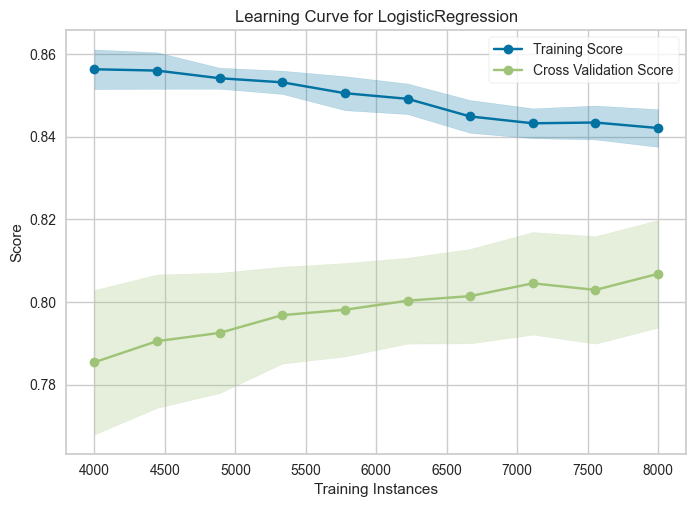

In [46]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(max_iter=1000), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

Воспользуемся классификатором на основе гребневой регрессии с сильной регуляризацией (недообучение):

In [47]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


Построим кривые обучения для недообученной модели:

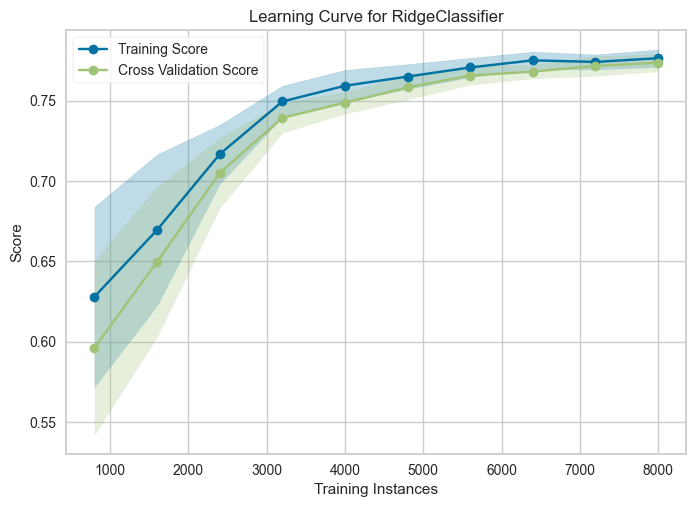

In [48]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

Построим график зависимости эффективности модели от значения параметра регуляризации:

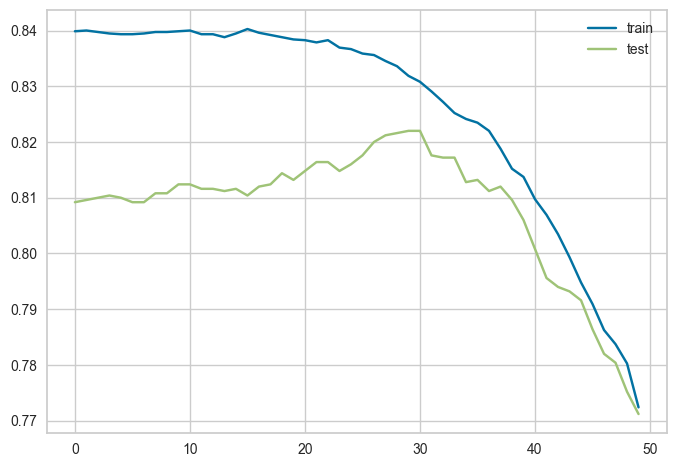

In [49]:
trains = []
tests = []
for i in np.logspace(2, 6, 50):
    ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label='train')
plt.plot(tests, label='test')
plt.legend()
plt.show()

Найдём оптимальное значение параметра регуляризации и оценим модель:

In [50]:
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


Построим кривые обучения для оптимальной модели:

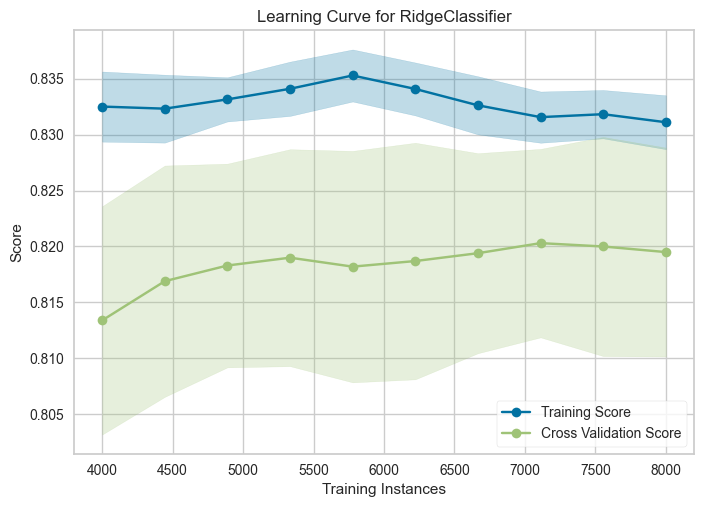

In [51]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

## 2. Диагностика моделей регрессии (Boston Housing)

Загрузим датасет цен на недвижимость:

In [52]:
from numpy import genfromtxt
dataset = genfromtxt('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML4.4%20diagnostics/data/diabetes.csv',delimiter=',',
    skip_header=1)
X = dataset[:,:-1]
y = dataset[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

Обучим линейную регрессию и оценим эффективность:

In [53]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train, y_train)
print(f"Training score: {lr.score(X_train, y_train):.2f}")
print(f"Test score: {lr.score(X_test, y_test):.2f}")

Training score: 0.29
Test score: 0.32


Построим кривые обучения для переобученной модели регрессии:

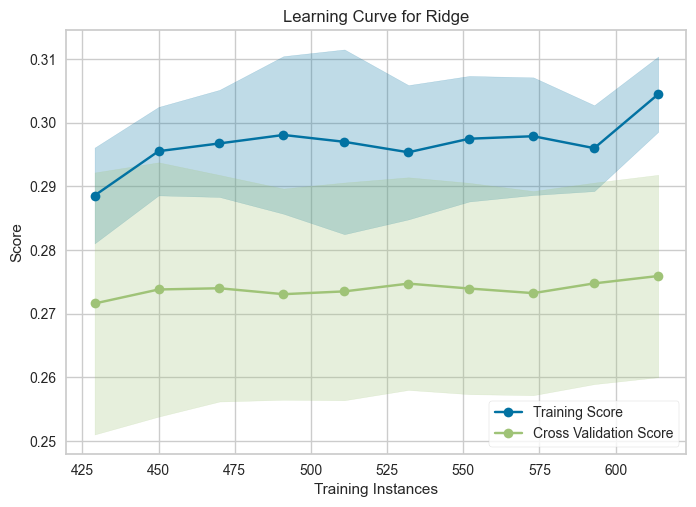

In [54]:
from yellowbrick.model_selection import LearningCurve
from sklearn.linear_model import Ridge

visualizer = LearningCurve(
    Ridge(alpha=0.0001), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y).show()

Построим график зависимости эффективности от параметра L2-регуляризации:

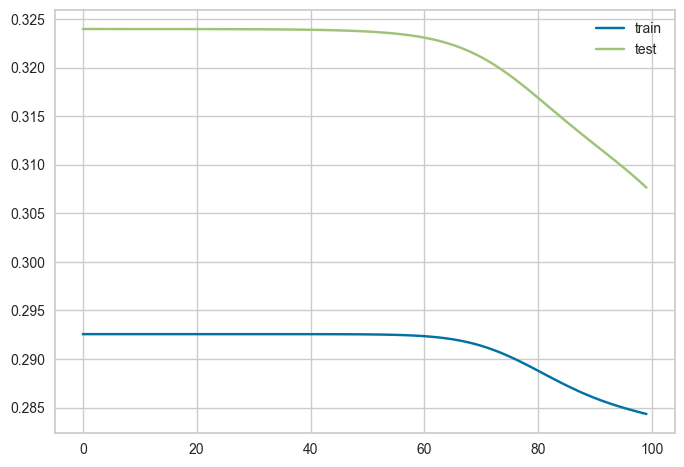

In [55]:
trains = []
tests = []
for i in np.logspace(-2, 3, 100):
    ridge = Ridge(alpha=i).fit(X_train, y_train)
    trains.append(ridge.score(X_train, y_train))
    tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

Оценим оптимальную модель:

In [56]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.29
Linear Regression-Test set score: 0.32


Построим кривые обучения для оптимальной модели регрессии:

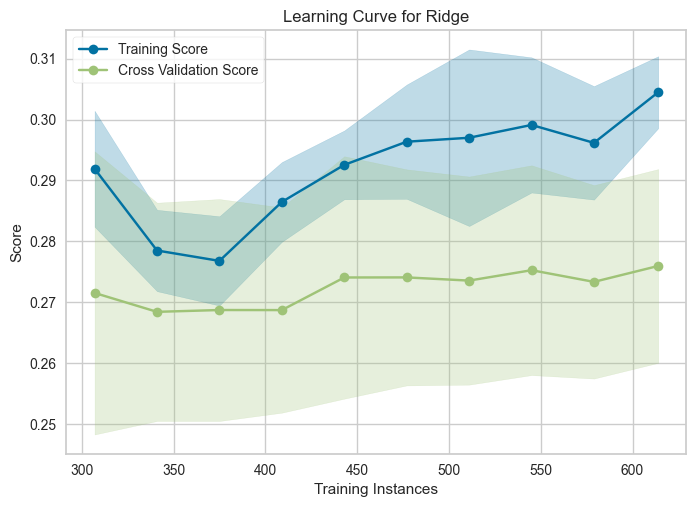

In [57]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

Построим кривые регуляризации для модели Lasso:

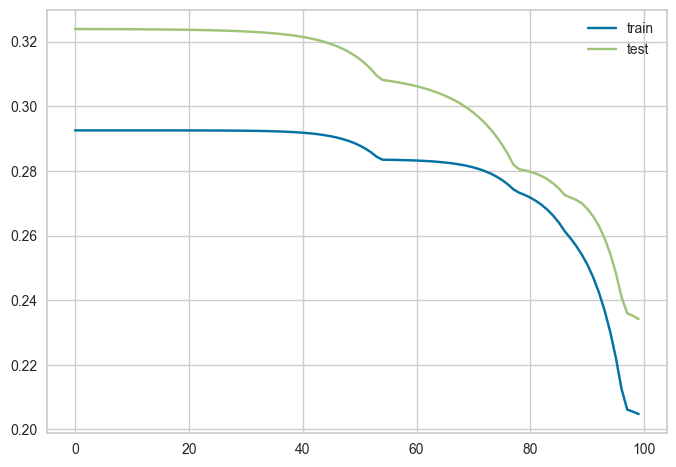

In [58]:
from sklearn.linear_model import Lasso

trains = []
tests = []
for i in np.logspace(-4, 0, 100):
    lasso = Lasso(alpha=i).fit(X_train, y_train)
    trains.append(lasso.score(X_train, y_train))
    tests.append(lasso.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()

## 3. Диагностика на реальных данных (диабет)

Загрузим данные (первые 200 строк):

In [59]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv', nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Подготовим данные:

In [60]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Обучим модель дерева решений без ограничений (переобучение):

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


Построим кривую обучения для переобученного дерева:

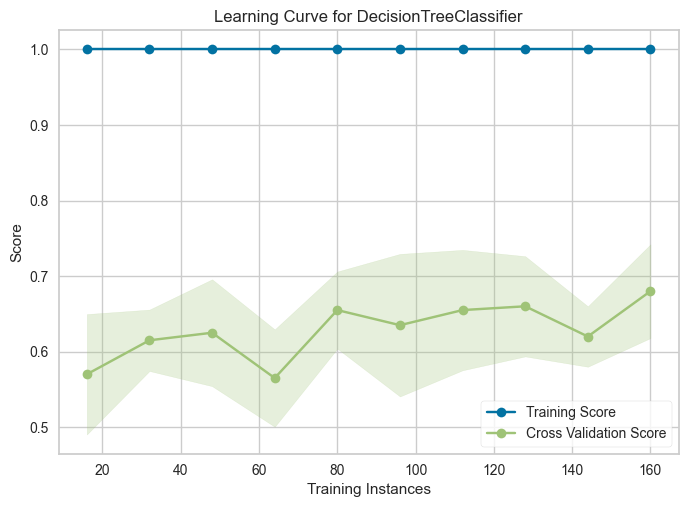

In [62]:
visualizer = LearningCurve(
    DecisionTreeClassifier(random_state=1), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

Регуляризуем дерево, ограничив глубину (max_depth=4):

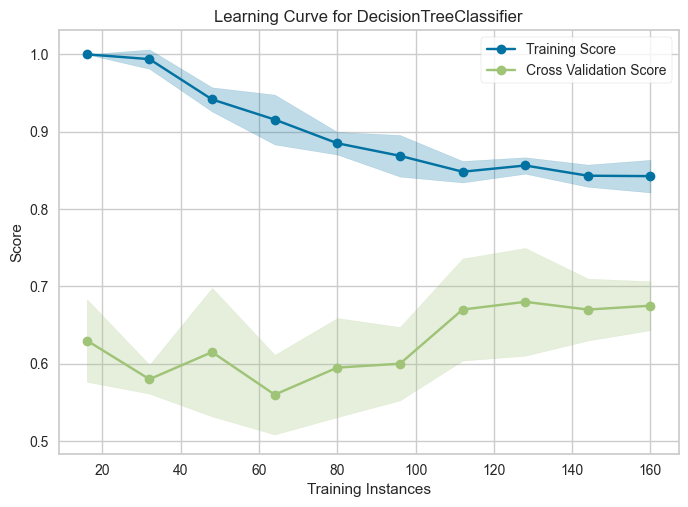

In [63]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

Оценим регуляризованную модель:

In [64]:
model = DecisionTreeClassifier(random_state=1, max_depth=4).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train f1_score = %.4f" % f1_score(y_train, y_train_pred))
print("Test f1_score = %.4f" % f1_score(y_test, y_pred))

Train f1_score = 0.7600
Test f1_score = 0.5455


Обучим нерегуляризованное дерево на полном датасете (борьба с переобучением добавлением данных):

In [65]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


## 4. Диагностика недообучения

Загрузим датасет delta_ailerons из OpenML:

In [66]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='delta_ailerons', parser="auto")
print(data.data.shape)

(7129, 5)


Подготовим данные:

In [67]:
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Обучим и оценим простую модель логистической регрессии:

In [68]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


Построим кривую обучения (признаки недообучения):

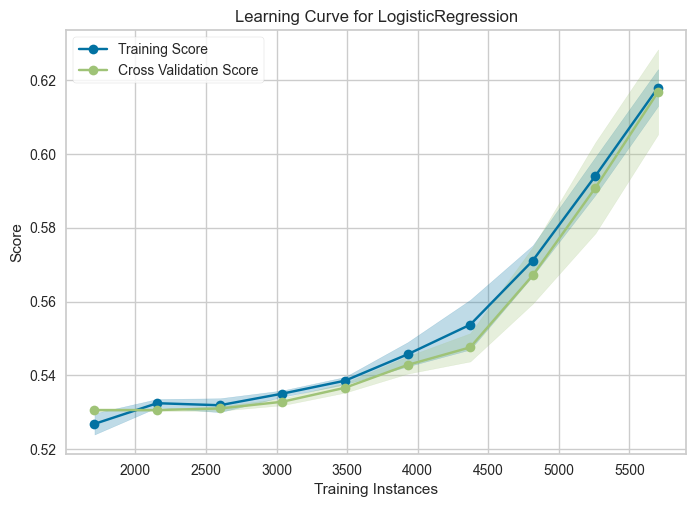

In [69]:
visualizer = LearningCurve(
    LogisticRegression(max_iter=1000), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y).show()

Усложним модель — используем многослойный перцептрон:

In [70]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(max_iter=1000).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9388
Test score = 0.9397


Построим кривую обучения для перцептрона:

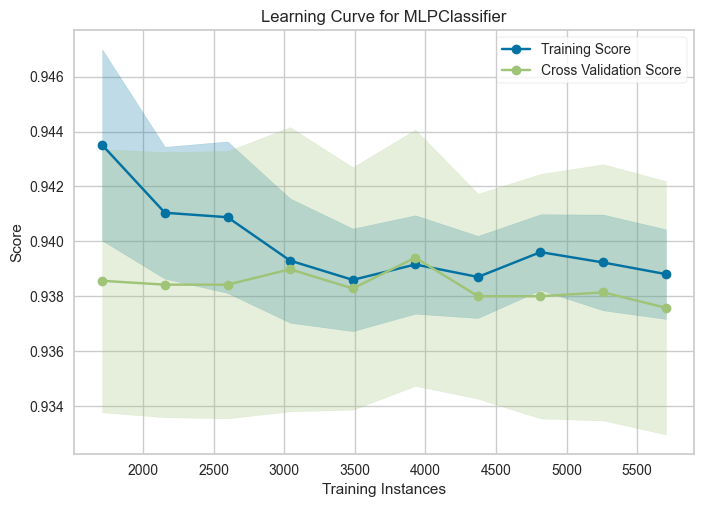

In [71]:
visualizer = LearningCurve(
    MLPClassifier(max_iter=1000), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y).show()

Введём полиномиальные признаки для усложнения модели:

In [72]:
from sklearn.preprocessing import PolynomialFeatures
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


Построим кривые регуляризации для полиномиальной модели:

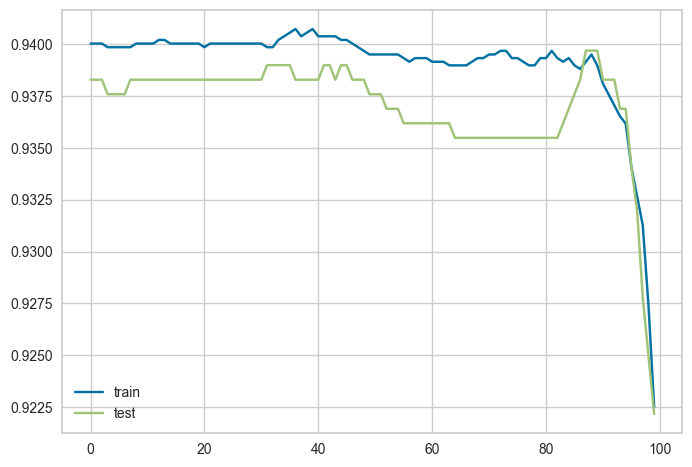

In [73]:
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
    ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
    trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
    tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()
plt.show()